# Elliptic Dataset

## Overview

From kaggle, we have the following description: 

The Elliptic Data Set maps Bitcoin transactions to real entities belonging to licit categories (exchanges, wallet providers, miners, licit services, etc.) versus illicit ones (scams, malware, terrorist organizations, ransomware, Ponzi schemes, etc.). The task on the dataset is to classify the illicit and licit nodes in the graph.

**Nodes and edges**

The graph is made of 203,769 nodes and 234,355 edges. Two percent (4,545) of the nodes are labelled class1 (illicit). Twenty-one percent (42,019) are labelled class2 (licit). The remaining transactions are not labelled with regard to licit versus illicit.

**Features**

There are 166 features associated with each node. Due to intellectual property issues, we cannot provide an exact description of all the features in the dataset. There is a time step associated to each node, representing a measure of the time when a transaction was broadcasted to the Bitcoin network. The time steps, running from 1 to 49, are evenly spaced with an interval of about two weeks. Each time step contains a single connected component of transactions that appeared on the blockchain within less than three hours between each other; there are no edges connecting the different time steps.

The first 94 features represent local information about the transaction – including the time step described above, number of inputs/outputs, transaction fee, output volume and aggregated figures such as average BTC received (spent) by the inputs/outputs and average number of incoming (outgoing) transactions associated with the inputs/outputs. The remaining 72 features are aggregated features, obtained using transaction information one-hop backward/forward from the center node - giving the maximum, minimum, standard deviation and correlation coefficients of the neighbour transactions for the same information data (number of inputs/outputs, transaction fee, etc.).

## Approach

We are going to tackle this problem applying a scalable distributed solution with Apache Spark. The things we need to note from the description is that this is a semi-supervised problem in a transductive setting, with data whose topology is a graph. We will make the pertinent hypothesis after the data analysis.

## Exploratory Data Analysis

In [1]:
import kagglehub, os


os.makedirs("data", exist_ok=True)

path = kagglehub.dataset_download("ellipticco/elliptic-data-set")
print("Path to dataset files:", path)

/home/silvia/.local/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: /home/silvia/.cache/kagglehub/datasets/ellipticco/elliptic-data-set/versions/1


In [ ]:
from pyspark.sql import SparkSession

spark = SparkSession \
    .builder \
    .master("local[*]") \
    .appName("Elliptic Dataset") \
    .config("spark.driver.memory", "4g") \
    .config("spark.executor.memory", "4g") \
    .config("spark.driver.maxResultSize", "2g") \
    .config("spark.sql.execution.arrow.pyspark.enabled", "true") \
    .getOrCreate()

sc = spark.sparkContext

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/04/14 18:54:21 WARN Utils: Your hostname, silvia-Thin-GF63-12UDX, resolves to a loopback address: 127.0.1.1; using 172.30.1.6 instead (on interface wlo1)
26/04/14 18:54:21 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/14 18:54:22 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [3]:
import pandas as pd


df_classes = pd.read_csv(
  path + "/elliptic_bitcoin_dataset/elliptic_txs_classes.csv"
)
df_classes = spark.createDataFrame(df_classes)

df_edges = pd.read_csv(
  path + "/elliptic_bitcoin_dataset/elliptic_txs_edgelist.csv"
)
df_edges = spark.createDataFrame(df_edges)

df_features = pd.read_csv(
  path + "/elliptic_bitcoin_dataset/elliptic_txs_features.csv",
  header=None
)
df_features = spark.createDataFrame(df_features)

/home/silvia/miniconda3/envs/elliptic/lib/python3.12/site-packages/pyspark/sql/pandas/conversion.py:416: UserWarning: createDataFrame attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  [PACKAGE_NOT_INSTALLED] PyArrow >= 15.0.0 must be installed; however, it was not found.
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)
/home/silvia/miniconda3/envs/elliptic/lib/python3.12/site-packages/pyspark/sql/pandas/conversion.py:416: UserWarning: createDataFrame attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  [PACKAGE_NOT_INSTALLED] PyArrow >= 15.0.0 must be installed; however, it was not found.
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)
/home/silvia/miniconda3/envs/elliptic/lib/python3.12/site-pa

In [4]:
df_classes.show(5)

Traceback (most recent call last):                                  (0 + 1) / 1]
  File "/home/silvia/miniconda3/envs/elliptic/lib/python3.12/site-packages/pyspark/python/lib/pyspark.zip/pyspark/daemon.py", line 233, in manager
    code = worker(sock, authenticated)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/silvia/miniconda3/envs/elliptic/lib/python3.12/site-packages/pyspark/python/lib/pyspark.zip/pyspark/daemon.py", line 87, in worker
    outfile.flush()
BrokenPipeError: [Errno 32] Broken pipe


+---------+-------+
|     txId|  class|
+---------+-------+
|230425980|unknown|
|  5530458|unknown|
|232022460|unknown|
|232438397|      2|
|230460314|unknown|
+---------+-------+
only showing top 5 rows


In [5]:
df_edges.show(5)

+---------+---------+
|    txId1|    txId2|
+---------+---------+
|230425980|  5530458|
|232022460|232438397|
|230460314|230459870|
|230333930|230595899|
|232013274|232029206|
+---------+---------+
only showing top 5 rows


In [6]:
df_features.show(5)

Traceback (most recent call last):
  File "/home/silvia/miniconda3/envs/elliptic/lib/python3.12/site-packages/pyspark/python/lib/pyspark.zip/pyspark/daemon.py", line 233, in manager
    code = worker(sock, authenticated)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/silvia/miniconda3/envs/elliptic/lib/python3.12/site-packages/pyspark/python/lib/pyspark.zip/pyspark/daemon.py", line 87, in worker
    outfile.flush()
BrokenPipeError: [Errno 32] Broken pipe
26/04/14 18:55:26 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
26/04/14 18:55:26 WARN TaskSetManager: Stage 2 contains a task of very large size (23933 KiB). The maximum recommended task size is 1000 KiB.


+---------+---+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+------------------+------------------+-------------------+-------------------+-------------------+-------------------+-------------------+------------------+-------------------+-------------------+-------------------+-------------------+---------

Traceback (most recent call last):
  File "/home/silvia/miniconda3/envs/elliptic/lib/python3.12/site-packages/pyspark/python/lib/pyspark.zip/pyspark/daemon.py", line 233, in manager
    code = worker(sock, authenticated)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/silvia/miniconda3/envs/elliptic/lib/python3.12/site-packages/pyspark/python/lib/pyspark.zip/pyspark/daemon.py", line 87, in worker
    outfile.flush()
BrokenPipeError: [Errno 32] Broken pipe


In [7]:
df_features = df_features.withColumnRenamed("0", "txId")
df_features.show(5)

+---------+---+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+------------------+------------------+-------------------+-------------------+-------------------+-------------------+-------------------+------------------+-------------------+-------------------+-------------------+-------------------+---------

26/04/14 18:55:26 WARN TaskSetManager: Stage 3 contains a task of very large size (23933 KiB). The maximum recommended task size is 1000 KiB.
Traceback (most recent call last):
  File "/home/silvia/miniconda3/envs/elliptic/lib/python3.12/site-packages/pyspark/python/lib/pyspark.zip/pyspark/daemon.py", line 233, in manager
    code = worker(sock, authenticated)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/silvia/miniconda3/envs/elliptic/lib/python3.12/site-packages/pyspark/python/lib/pyspark.zip/pyspark/daemon.py", line 87, in worker
    outfile.flush()
BrokenPipeError: [Errno 32] Broken pipe


As we can see, the majority of features do not really have a lot of semantic meaning. But, from kaggle, we know that there is another important feature, which is the timestamp. The column '1' seems suspecting, we will check it.

In [8]:
df_features.describe("1").show()

26/04/14 18:55:27 WARN TaskSetManager: Stage 4 contains a task of very large size (23933 KiB). The maximum recommended task size is 1000 KiB.


+-------+------------------+
|summary|                 1|
+-------+------------------+
|  count|            203769|
|   mean|23.843960563186744|
| stddev|15.172170045043556|
|    min|                 1|
|    max|                49|
+-------+------------------+



It matches with the kaggle text, so we rename the column.

In [9]:
df_features = df_features.withColumnRenamed("1", "timestamp")
df_features.show(5)

26/04/14 18:55:29 WARN TaskSetManager: Stage 7 contains a task of very large size (23933 KiB). The maximum recommended task size is 1000 KiB.
Traceback (most recent call last):
  File "/home/silvia/miniconda3/envs/elliptic/lib/python3.12/site-packages/pyspark/python/lib/pyspark.zip/pyspark/daemon.py", line 233, in manager
    code = worker(sock, authenticated)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/silvia/miniconda3/envs/elliptic/lib/python3.12/site-packages/pyspark/python/lib/pyspark.zip/pyspark/daemon.py", line 87, in worker
    outfile.flush()
BrokenPipeError: [Errno 32] Broken pipe


+---------+---------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+------------------+------------------+-------------------+-------------------+-------------------+-------------------+-------------------+------------------+-------------------+-------------------+-------------------+-------------------+---

It is always good practice to check the possible null values.

In [10]:
import pyspark.sql.functions as sql_f


df_null = df_features.select([
    sql_f.count(sql_f.when(sql_f.col(c).isNull() | sql_f.isnan(c), c)).alias(c) for c in df_features.columns
])

df_null.show()

26/04/14 18:55:30 WARN TaskSetManager: Stage 8 contains a task of very large size (23933 KiB). The maximum recommended task size is 1000 KiB.


+----+---------+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+
|txId|timestamp|  2|  3|  4|  5|  6|  7|  8|  9| 10| 11| 12| 13| 14| 15| 16| 17| 18| 19| 20| 21| 22| 23| 24| 25| 26| 27| 28| 29| 30| 31| 32| 33| 34| 35| 36| 37| 38| 39| 40| 41| 42| 43| 44| 45| 46| 47| 48| 49| 50| 51| 52| 53| 54| 55| 56| 57| 58| 59| 60| 61| 62| 63| 64| 65| 66| 67| 68| 69| 70| 71| 72| 73| 74| 75| 76| 77| 78

We will check now the classes to see how they are distributed, since the description in kaggle seems to point to a severe case of class imbalance.

/home/silvia/miniconda3/envs/elliptic/lib/python3.12/site-packages/pyspark/sql/pandas/conversion.py:94: UserWarning: toPandas attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  [PACKAGE_NOT_INSTALLED] PyArrow >= 15.0.0 must be installed; however, it was not found.
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)


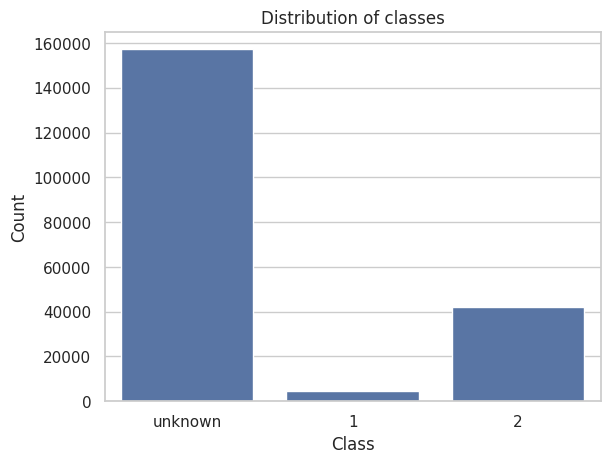

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style="whitegrid")

df_count = df_classes.groupBy("class").count().toPandas()

sns.barplot(x="class", y="count", data=df_count)
plt.title("Distribution of classes")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

If we recall from the description, "Each time step contains a single connected component of transactions that appeared on the blockchain within less than three hours between each other; there are no edges connecting the different time steps.". We will check this and further explore the timestamp column.

In [16]:
f1 = df_features.alias("f1")
f2 = df_features.alias("f2")

df_joined = df_edges \
    .join(f1, sql_f.col("txId1") == sql_f.col("f1.txId"), "inner") \
    .join(f2, sql_f.col("txId2") == sql_f.col("f2.txId"), "inner")

df_final = df_joined.select(
    sql_f.col("f1.timestamp").alias("timestamp_1"),
    sql_f.col("f2.timestamp").alias("timestamp_2")
)

df_final.show(5)

print(f"Number of rows of the joined dataframe: {df_final.count()}")

distinct_count = df_final.filter(sql_f.col("timestamp_1") != sql_f.col("timestamp_2")).count()
print(f"Number of edges where the timestamps are different for each node: {distinct_count}")

26/04/14 19:13:04 WARN TaskSetManager: Stage 68 contains a task of very large size (23933 KiB). The maximum recommended task size is 1000 KiB.


+-----------+-----------+
|timestamp_1|timestamp_2|
+-----------+-----------+
|          1|          1|
|          1|          1|
|          1|          1|
|          1|          1|
|          1|          1|
+-----------+-----------+
only showing top 5 rows


26/04/14 19:13:06 WARN TaskSetManager: Stage 74 contains a task of very large size (23933 KiB). The maximum recommended task size is 1000 KiB.


Number of rows of the joined dataframe: 234355


26/04/14 19:13:07 WARN TaskSetManager: Stage 83 contains a task of very large size (23933 KiB). The maximum recommended task size is 1000 KiB.


Number of edges where the timestamps are different for each node: 0


It is interesting to explore the class distribution grouped by timestamps.

In [31]:
df_dist = df_features.join(df_classes, "txId", "inner")
df_dist = df_dist.filter(df_dist["class"] != "unknown")
df_dist = df_dist.groupBy(sql_f.col("timestamp")).\
    agg(sql_f.avg(sql_f.when(df_dist["class"] == 1, 1).otherwise(0)).alias("ratio_classes"))

df_dist.orderBy("timestamp").show()

26/04/14 19:34:04 WARN TaskSetManager: Stage 204 contains a task of very large size (23933 KiB). The maximum recommended task size is 1000 KiB.


+---------+--------------------+
|timestamp|       ratio_classes|
+---------+--------------------+
|        1|0.007918025151374011|
|        2| 0.01611459265890779|
|        3|0.008600469116497263|
|        4|0.020833333333333332|
|        5|0.004250797024442083|
|        6|0.010309278350515464|
|        7| 0.08478802992518704|
|        8| 0.05751072961373391|
|        9| 0.31876606683804626|
|       10|0.018518518518518517|
|       11|  0.1882183908045977|
|       12| 0.03162055335968379|
|       13| 0.35970333745364647|
|       14| 0.10311750599520383|
|       15| 0.23786407766990292|
|       16| 0.24150943396226415|
|       17|  0.1220715166461159|
|       18| 0.13367609254498714|
|       19| 0.10738255033557047|
|       20| 0.28888888888888886|
+---------+--------------------+
only showing top 20 rows


In [32]:
df_dist = df_dist.toPandas()

/home/silvia/miniconda3/envs/elliptic/lib/python3.12/site-packages/pyspark/sql/pandas/conversion.py:94: UserWarning: toPandas attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  [PACKAGE_NOT_INSTALLED] PyArrow >= 15.0.0 must be installed; however, it was not found.
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)
26/04/14 19:34:09 WARN TaskSetManager: Stage 213 contains a task of very large size (23933 KiB). The maximum recommended task size is 1000 KiB.


/tmp/ipykernel_22594/1012860741.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


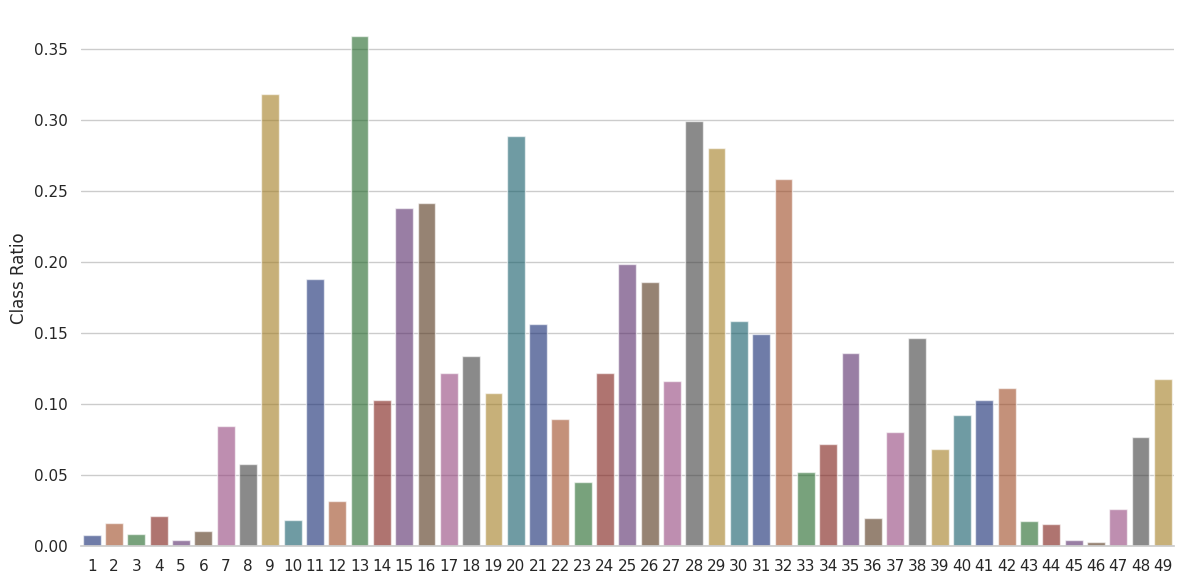

In [37]:
g = sns.catplot(
    data=df_dist, kind="bar",
    x="timestamp", y="ratio_classes",
    errorbar="sd", palette="dark", alpha=.6, height=6, 
    aspect=2
)
g.despine(left=True)
g.set_axis_labels("", "Class Ratio")

plt.tight_layout()
plt.show()

As we can see, the imbalance is still pretty much a problem across all buckets.

## Model Training

We are not able to train just with tabular algorithms, since we also desire to take advantage of the topology of the graph itself. A very natural approach is to use GNNs, since they are able to aggregate both topology and node (and potentially edge) features, in a way that a transductive problem can be solved effectively. On the other hand, we are in a distributive setting. Implementing our own distributed training of a deep learning model might be extremely challenging. Spark has already implemented solutions for this, but, for learning purposes, we will try to implement our own approaches. 

A somewhat natural way of using GNNs in a distributing setting is training a model in each worker and then aggregating the result in some way. There is some interesting structure surrounding the timestamp property, meaning, the nature of the data is of disjoint graph components. We could make a hypothesis here: there is no preference on when the licit/illicit transactions might happen in time, and thus there might be some time invariance that we could exploit. We can experiment with the data partitioning in any case, applying either this partitioning strategy or another more classical sampling with replacement. Federated learning is here the most natural solution. In particular, assuming I.I.D., which is reasonable according to our hypothesis, FedAVG should work fine.

### GNNs overview

There are several types of GNNs, but we will focus on Graph Convolutional Networks (GCNs). These models are convolutional in the sense that update each node by aggregating information from nearby nodes, and as such, they induce a relational inductive bias [1]. Each layer of the GCN can be described as a function $F[\bullet]$ with parameters $\Phi$ that takes the node embeddings and adjacency matrix and outputs new node embeddings:

$$H_1 = F[X, A, \Phi_0]$$
$$H_2 = F[H_1, A, \Phi_1]$$
$$\vdots$$
$$H_K = F[H_{K-1}, A, \Phi_{K-1}]$$

where $X$ is the input, $A$ the adjacency matrix, $H_k$ contains the modified node embeddings at the $k$-th layer, and $\Phi_k$ are the parameters associated with that layer. At the level of a single node, we have:

$$h_{k+1}^{(n)} = a[\beta_k + \Omega_k \cdot h_{k}^{(n)} + \Omega_k \cdot agg[n,k]]$$

where $a[\bullet]$ is the activation function, $\Omega_k$ is a linear transformation and $agg[\bullet]$ is an aggregation function on the neighborhood of the node, which could be just the sum of the neighbour embeddings. At the level of a whole layer, this can be written as:

$$H_{k+1} = a[\beta_k 1^T + \Omega_k H_{k} + \Omega_k H_k A] = a[\beta_k 1^T + \Omega_k H_{k} (A + I)]$$

In a more informal way, a GCN enriches the input embeddings of the graph nodes with information of their surroundings, outputting an enriched embedding for each node. This makes a GCN particularly suitable for transductive settings. In particular, for our purposes of node binary classification, the final layer should be of the following form:

$$f[X, A, \Phi] = sig[\beta_K 1^T + w_K H_K]$$

where $sig[\bullet]$ is a sigmoid function that gets applied independently to every element of the row vector input, necessary because we want to establish a probability distribution over the possible labels; since we are in a binary setting, we don't need a softmax. In other words, in the end we will have a predicted label $y^{(n)}$ for each node $n$ of the graph. The loss will then be a usual binary cross entropy, but with a couple of caveats:

- It will only be applied to the nodes for which we have a ground truth, meaning we will need to apply a mask. This shows why a GNN is so suitable for our purposes: the unlabeled nodes will simply be classified like any other node.
- Our classes are severely unbalanced. We can apply here other strategies, but the most simple one is modifying the loss function. We will try to apply weighting to penalize errors in the minority class [2].

The binary cross entropy loss function can be written as:

$$l(y, \hat{y}) = - (1 - y) \log(1 - \hat{y}) - y \log(\hat{y})$$

where $y \in \{1, -1\}$ is the ground truth label and $\hat{y} \in [0, 1]$ is the probability predicted by the model. The weighted cross entropy will just be:

$$l(y, \hat{y}) = - [\alpha \cdot (1 - y) \log(1 - \hat{y}) + \beta \cdot y \log(\hat{y})]$$

where $\alpha, \beta$ are hyperparameters, but they can be computed as:

$$\alpha = \frac{N}{2 \cdot \sum_{i=1}^{N} \mathbf{1}_{A}(y_i = -1)}$$
$$\beta = \frac{N}{2 \cdot \sum_{i=1}^{N} \mathbf{1}_{A}(y_i = 1)}$$

where $N$ is the dataset size.

### Boosting overview

We will try to implement a version of AdaBoost. In AdaBoost, each example has an associated weight that represents its importance, and the models are learned sequentially using these weights, which are modified through iterations. Initially, it trains a model with all the examples having the same importance (weights). Then, the weights of the examples are modified. The weights of misclassified instances are increased. Conversely, the weights of correctly classified instances are decreased. The objective is to give more importance to the examples that are hard to classify [3].

In addition to the weights of the examples, in AdaBoost, a weight is assigned to each individual classifier, which is used when predicting new examples. This weight depends on the error each model makes on the training set (taking the weight distribution into account). The idea is to give more weight to those classifiers that perform better at that stage. As such, the method only has one key hyperparameter, the number of classifiers/iterations [3].

**AdaBoost Algorithm [3]**

```
Input: 

TR: Training set, n: Boostrap size, Learner: Weak learner, MaxIter
weights [i] = 1/size(TR) for i = 1,..., size(TR)

Computation:

for t = 1 to MaxIter:
    models[t] = Learner.fit(TR, weights)
    predictions = models[t].predict(TR)
    error = Sum of weights of misclassified TR instances

    if error › 0.5:
        Disregard model and break

    alpha[t] = 1/2 * ln((1-error) /error)
    for i = 1 to size(TR):
        weights [i] *= exp(-alpha * prediction[i] * TR[i].output)
    Normalize weights to be a distribution (sum up to 1)
return models
```

We are going to clarify some of the formulas. First, the errors of the classifier are computed as:

$$\epsilon_t = \sum_{i=1}^{N} w_{i}^{(t)} \cdot \mathbf{1}_{A}(y_i \neq h_t(x_i))$$

Nothing special about this, the usual error of a classifier gets weighted by the current weights. The weight of the model $t$ after training is:

$$\alpha_t = \frac{1}{2} \log\left(\frac{1 - \epsilon_t}{\epsilon_t}\right)$$

What we need to keep in mind with this formula is that good classifiers get rewarded (the fraction inside the $\log$ will be big if $\epsilon_t$ is small, and the $\log$ itself will be somewhat big and positive), random classifiers get completely ignored ($\log(1)=0$) and "worse than coin flipping" classifiers will get flipped ($\alpha_t < 0$). Finally, the weight update for the instances will be:

$$w_{i}^{(t+1)} = \frac{w_{i}^{(t)} \exp(-\alpha_t \cdot y_i \cdot h_t(x_i))}{Z_t}$$

The exponent in the exponential "flips" the results of training, so that misclassified instances get more importance. The $\exp(\bullet)$ of something negative gives a value in the interval $[0,1]$, so the weight gets reduced when the instance has been correctly classified. On the other hand, misclassifications get a positive exponent, so the $\exp(\bullet)>1$ and the weight will get bigger. Finally, $Z_t$ is just a normalization term.

### Implementation

First, we start with the implementation of the GCN. For that, we will be using PyTorch Geometric.

In [ ]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv


class GCN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self._conv1 = GCNConv(in_channels, hidden_channels, normalize=False)
        self._conv2 = GCNConv(hidden_channels, out_channels, normalize=False)

    def forward(self, x, edge_index, edge_weight):
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.conv1(x, edge_index, edge_weight).relu()
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.conv2(x, edge_index)
        return x

We will need to send the training process to each worker. For this, we will define a Pandas UDF (code adapted from [4]).

In [ ]:
import numpy as np
from torch_geometric.data import Data, DataLoader


EPOCHS = 201

def train(model, optimizer, data, weights):
    model.train()
    optimizer.zero_grad()

    # The forward pass is done without any mask
    out = model(data.x, data.edge_index, data.edge_weight)

    # This loss function applies a sigmoid + weighted binary cross entropy
    loss = torch.nn.BCEWithLogitsLoss(weight=weights)

    # The backward pass needs masking
    output = loss(out[data.train_mask], data.y[data.train_mask])
    output.backward()
    optimizer.step()

    return float(loss.detach())

@torch.no_grad
def test(model, data):
    model.eval()
    pred = model(data.x, data.edge_index, data.edge_weight).argmax(dim=-1)

    accs = []
    for mask in [data.train_mask, data.val_mask, data.test_mask]:
        accs.append(int((pred[mask] == data.y[mask]).sum()) / int(mask.sum()))
    return accs

def draw_metrics(losses, train_accs, val_accs, test_accs):
    plt.figure(figsize=(12, 6))

    # Loss plot
    plt.subplot(1, 2, 1)
    plt.plot(losses, label="Train Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss Evolution")
    plt.legend()

    # Accuracy plot
    plt.subplot(1, 2, 2)
    plt.plot(train_accs, label="Train Accuracy")
    plt.plot(val_accs, label="Validation Accuracy")
    plt.plot(test_accs, label="Test Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Accuracy Evolution")
    plt.legend()

    plt.tight_layout()
    plt.show()

def train_local_gcn(pdf_iterator):
    # Spark returns the partition as an iterator with apache arrow
    pdf = pd.concat(list(pdf_iterator))
    row = pdf.iloc[0]

    # Data tensors
    x = torch.tensor(row['features'], dtype=torch.float)
    edge_index = torch.tensor(row['edge_index'], dtype=torch.long).t().contiguous()
    y = torch.tensor(row['class'], dtype=torch.long)
    num_nodes = x.size(0)

    # Calculates the weights for the weighted loss
    w_0 = num_nodes / (2 * pdf.where(pdf["class"] == 1).values.sum())
    w_1 = num_nodes / (2 * pdf.where(pdf["class"] == 2).values.sum())
    weights = torch.tensor([w_0, w_1])

    # Mask generation (split of 0.7, 0.15, 0.15)
    rand_tensor = torch.rand(num_nodes)
    train_mask = rand_tensor < 0.70
    val_mask = (rand_tensor >= 0.70) & (rand_tensor < 0.85)
    test_mask = rand_tensor >= 0.85

    # PyG Data object that represents the graph
    data = Data(
        x=x, 
        edge_index=edge_index, 
        y=y,
        train_mask=train_mask,
        val_mask=val_mask,
        test_mask=test_mask
    )

    model = GCN(
        in_channels=x.shape[1],
        hidden_channels=16,
        out_channels=2,
    ).to('cpu')

    optimizer = torch.optim.Adam([
        dict(params=model.conv1.parameters(), weight_decay=5e-4),
        dict(params=model.conv2.parameters(), weight_decay=0)
    ], lr=0.01)  # Only perform weight-decay on first convolution.

    # Lists for keeping the metrics
    losses = []
    train_accs = []
    val_accs = []
    test_accs = []

    # Trains in full batch
    for _ in range(1, EPOCHS):
        loss = train(model, optimizer, data, weights)
        train_acc, val_acc, test_acc = test(model, data)

        losses.append(loss); train_accs.append(train_acc)
        val_accs.append(val_acc); test_accs.append(test_acc)

    draw_metrics(losses, train_accs, val_accs, test_accs)

    state_dict = model.state_dict()

    dfs = []
    for layer_name, tensor in state_dict.items():
        # Flatten tensor to 1D vector
        flat_array = tensor.cpu().detach().numpy().flatten()
        
        # Temporal dataframe for this layer with the indices
        layer_df = pd.DataFrame({
            'layer_name': layer_name,
            'param_index': np.arange(len(flat_array)),
            'param_value': flat_array
        })
        dfs.append(layer_df)
        
    exploded_weights = pd.concat(dfs, ignore_index=True)
    exploded_weights['partition_id'] = row['partition_id']
    exploded_weights['n_samples'] = num_nodes 
    
    yield exploded_weights

We will now implement the main Spark process. We will investigate two alternatives, as we have discussed: partitioning the data via the timestamp or via usual random sampling. We need to also implement the federated learning procedure itself.

In [ ]:
def random_partition(df_nodes):
    # Random partitioning according to the threads available
    cpu_threads = spark.sparkContext.defaultParallelism
    df_nodes = df_nodes.repartition(cpu_threads)
    df_nodes = df_nodes.withColumn(sql_f.spark_partition_id().alias("partition_id"))

    return df_nodes

def timestamp_partition(df_nodes):
    # Partitioning by timestamp, limiting by threads available
    cpu_threads = spark.sparkContext.defaultParallelism
    df_nodes = df_nodes.repartition(cpu_threads, "timestamp")
    df_nodes = df_nodes.withColumn(sql_f.spark_partition_id().alias("partition_id"))

    return df_nodes

In [ ]:
from pyspark.ml.feature import VectorAssembler, MinMaxScaler
from pyspark.ml import Pipeline
from pyspark.ml.functions import vector_to_array


def preprocess_data(df_features, df_classes, df_edges, partition="random"):
    # Normalization
    float_cols = [field[0] for field in df_features.dtypes if field[1] in ('float', 'double')]
    assembler = VectorAssembler(inputCols=float_cols, outputCol="features_vector")
    scaler = MinMaxScaler(inputCol="features_vector", outputCol="scaled_vector")
    pipeline = Pipeline(stages=[assembler, scaler])
    model = pipeline.fit(df_features)
    df_features = model.transform(df_features)
    df_features = df_features.withColumn("scaled_array", vector_to_array("scaled_vector"))
    for i, col_name in enumerate(float_cols):
        df_features = df_features.withColumn(col_name, F.col("scaled_array").getItem(i))
    df_features = df_features.drop("features_vector", "scaled_vector", "scaled_array")

    # Collects all the features as arrays in a single column "features"
    df_features = df_features.withColumn("features", sql_f.array(*float_cols))
    df_features = df_features.drop(*float_cols)

    # Join of the features dataframe with the classes
    df_nodes = df_features.join(df_classes, "txId")

    # Partition strategy
    if partition == "random":
        df_nodes = random_partition(df_nodes)
    else:
        df_nodes = timestamp_partition(df_nodes)

    # Obtains the partition_id of the node 1, joinning the edge
    # and node dataframes so that each row is an edge.
    df_edges = df_edges.join(
        df_nodes.select(sql_f.col("txId").alias("txId1"), sql_f.col("partition_id").alias("partition_id_1")),
        on="txId1", how="inner"
    )

    # Obtains the partition_id of the second node and filter cutted edges
    df_edges = df_edges.join(
        df_nodes.select(sql_f.col("txId").alias("txId2"), sql_f.col("partition_id").alias("partition_id_2")),
        on="txId2", how="inner"
    ).filter(sql_f.col("partition_id_1") == sql_f.col("partition_id_2")) \
    .drop("partition_id_2").withColumnRenamed("partition_id_1", "partition_id")

    # Groups nodes by partition_id and collects columns into lists
    df_nodes_agg = df_nodes.groupBy("partition_id").agg(
        sql_f.collect_list("txId").alias("txId"),
        sql_f.collect_list("features").alias("features"),
        sql_f.collect_list("class").alias("class")
    )

    # Groups edges by partition_id
    df_edges_agg = df_edges.withColumn("edge_pair", sql_f.array("txId1", "txId2")) \
        .groupBy("partition_id").agg(
            sql_f.collect_list("edge_pair").alias("edge_pair")
        )

    df_data = df_nodes_agg.join(df_edges_agg, on="partition_id", how="left")
    return df_data

In [ ]:
from pyspark.sql.types import *


def federated_avg(df_param):
    total_samples = df_param.select(sql_f.sum("n_samples")).first()[0]

    # FedAVG, weighted average per individual parameter
    df_avg = df_param.withColumn(
        "weighted_val", 
        sql_f.col("param_value") * (sql_f.col("n_samples") / total_samples)
    ).groupBy("layer_name", "param_index").agg(
        sql_f.sum("weighted_val").alias("avg_param_value")
    )

    # Array reconstruction, group by layer y ordenamos por el índice
    df_global = df_avg.withColumn(
        # Empaquetamos índice y valor juntos
        "indexed_val", sql_f.struct("param_index", "avg_param_value")
    ).groupBy("layer_name").agg(
        # array_sort ordena basándose en el primer elemento del struct (el param_index)
        sql_f.array_sort(sql_f.collect_list("indexed_val")).alias("sorted_params")
    ).select(
        "layer_name",
        # Extraemos solo el valor numérico, ya ordenado, descartando el índice
        sql_f.transform("sorted_params", lambda x: x.avg_param_value).alias("flat_weights")
    )

    return df_global

In [ ]:
num_features = len(df_features.columns) - 1
df_data = preprocess_data(df_features, df_classes, df_edges, partition="timestamp")

schema = StructType([
    StructField("partition_id", LongType(), True),
    StructField("layer_name", StringType(), True),
    StructField("param_value", LongType(), True),
])

df_param = df_data.groupby("partition_id").mapInPandas(train_local_gcn, schema=schema)
df_global = federated_avg(df_param)

In [ ]:
import torch


global_weights = df_global.collect()
global_weights_dict = {row['layer_name']: row['flat_weights'] for row in global_weights}

global_model = GCN(
    in_channels=num_features,
    hidden_channels=16,
    out_channels=2,
).to('cpu')

original_state_dict = global_model.state_dict()

new_state_dict = {}
for layer_name, flat_weights in global_weights_dict.items():
    expected_shape = original_state_dict[layer_name].shape
    reconstructed_tensor = torch.tensor(flat_weights).reshape(expected_shape)
    new_state_dict[layer_name] = reconstructed_tensor

global_model.load_state_dict(new_state_dict)

## References

- [4] pyg-team. (s.f.). gcn.py [Source code]. GitHub. Recovered april 18th 2026, from https://github.com/pyg-team/pytorch_geometric/blob/master/examples/compile/gcn.py